# Conditional Co-Recall by Category

> Measure whether recalled items pull same-category neighbors into recall more than different-category neighbors.

Conditional co-recall by category measures how the probability that a neighbor was recalled depends on whether it belongs to the same or a different category as a recalled anchor item. For a given reference category, each recalled anchor from that category contributes to two bins: same-category neighbors and different-category neighbors.

A higher same-category probability relative to different-category indicates within-category clustering in recall, even after controlling for the anchor being recalled.

## Workflow

In [ ]:
import os
import warnings
from jaxcmr.analyses.conditional_corec_by_cat import plot_conditional_corec_by_cat
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [6]:
dataset_name = "CohenKahana2022_noELI"
figure_dir = "results/figures"
figure_str = ""
trial_query = "data['subject'] > 0"
category_field = "valence"
category_value = -1
relation_labels = ["Neg->Neg", "Neg->Other"]
confidence_level = 0.95

In [7]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, "data", f"{dataset_name}.h5")
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

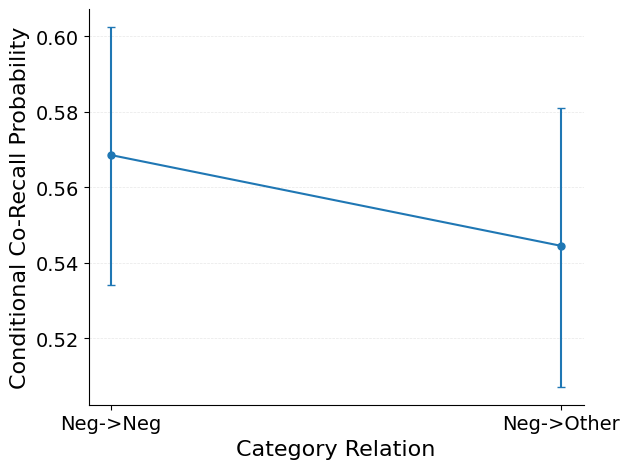

In [8]:
plot_conditional_corec_by_cat(
    data,
    trial_mask,
    category_field=category_field,
    category_value=category_value,
    relation_labels=relation_labels,
    confidence_level=confidence_level,
)
save_figure(figure_dir, figure_str)

## Interpretation

The plot compares co-recall probabilities for same-category and different-category neighbors of recalled anchor items. Key patterns:

- **Same > Different**: recalled anchors preferentially pull same-category neighbors into recall, indicating category clustering.
- **Same ≈ Different**: category membership does not predict co-recall beyond baseline.

## API Details

### Notebook parameters

- `dataset_name` — name of the dataset (used to construct the HDF5 path as `data/{dataset_name}.h5`).
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `category_field` — name of the field in the dataset containing category labels.
- `category_value` — the category value defining the anchor group.
- `relation_labels` — list of two labels for the legend: `[same_label, different_label]`.
- `confidence_level` — confidence level for subject-wise error bars.